In [1]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib import cm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from pathlib import Path

In [2]:
with open('/home/annierosen16/pressure.pkl', 'rb') as f:
    
    pressure = pickle.load(f)
    
with open('/home/annierosen16/sgp_latitudes.pkl', 'rb') as f:
    
    latitude = pickle.load(f)
    
with open('/home/annierosen16/sgp_longitudes.pkl', 'rb') as f:
    
    longitude = pickle.load(f)

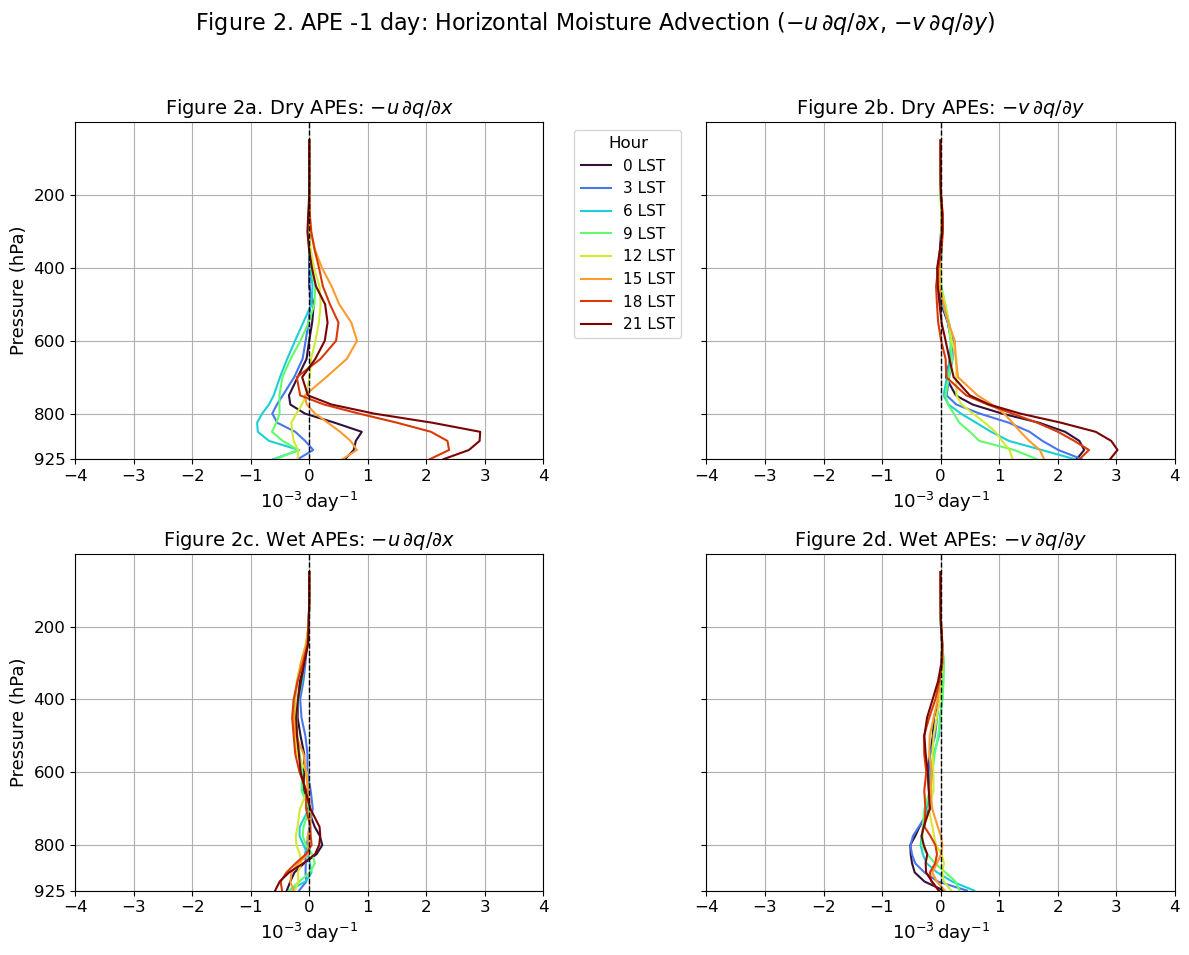

In [3]:
# these are the correct version -> using a single gridpoint to center the APE, and gradients with only adjacent points

folder = Path.home() / "advection_profiles_single_gridpoint_2001_2025_preapes"

# --- hours you want to plot ---

hours = [0, 3, 6, 9, 12, 15, 18, 21]

# --- storage dictionaries ---
zonal_advection_data = {}

meridional_advection_data = {}

# --- load data for each hour ---
for hr in hours:
    
    fp = folder / f"{hr}lst_advection_profile_preape.pkl"
    
    with open(fp, "rb") as f:
        
        data = pickle.load(f)

    # store
    
    zonal_advection_data[hr] = data['zonal'] 
    
    meridional_advection_data[hr] = data['meridional'] 

# --- assume pressure is identical for all files ---

pressure = np.array(pressure)

pressure_masked = pressure[pressure <= 925]

# --- Set up figure ---
colors = plt.cm.turbo(np.linspace(0, 1, len(hours)))

fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

axs = axs.flatten()

titles = [
    r"Figure 2a. Dry APEs: $-u \, \partial q / \partial x$",
    r"Figure 2b. Dry APEs: $-v \, \partial q / \partial y$",
    r"Figure 2c. Wet APEs: $-u \, \partial q / \partial x$",
    r"Figure 2d. Wet APEs: $-v \, \partial q / \partial y$"
]

# plotting loop
for i, hr in enumerate(hours):
    
    color = colors[i]

    # extract profiles, mask to same pressure mask
    zon_dry = np.array(zonal_advection_data[hr]["predry"]*1000)[pressure <= 925]
    
    mer_dry = np.array(meridional_advection_data[hr]["predry"]*1000)[pressure <= 925]
    
    zon_wet = np.array(zonal_advection_data[hr]["prewet"]*1000)[pressure <= 925]
    
    mer_wet = np.array(meridional_advection_data[hr]["prewet"]*1000)[pressure <= 925]

    axs[0].plot(zon_dry, pressure_masked, color=color, label=f"{hr} LST")
    
    axs[1].plot(mer_dry, pressure_masked, color=color)
    
    axs[2].plot(zon_wet, pressure_masked, color=color)
    
    axs[3].plot(mer_wet, pressure_masked, color=color)

# Style subplots
for ax, title in zip(axs, titles):
    
    ax.set_title(title, fontsize=14)
    
    ax.set_xlim(-4, 4)
    
    ax.set_ylim(0, np.max(pressure_masked))
    
    yticks = [925, 800, 600, 400, 200]
    
    ax.set_yticks(yticks)
    
    ax.set_yticklabels([str(int(p)) for p in yticks], fontsize=12)
    
    ax.set_xlabel(r"$10^{-3} \, \mathrm{day}^{-1}$", fontsize=13)
    
    ax.grid(True)
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    
    ax.tick_params(axis='x', labelsize=12)
    
    ax.tick_params(axis='y', labelsize=12)

# labels on left panels
axs[0].set_ylabel("Pressure (hPa)", fontsize=13)

axs[2].set_ylabel("Pressure (hPa)", fontsize=13)

axs[0].legend(title="Hour", fontsize=11, title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle(r"Figure 2. APE -1 day: Horizontal Moisture Advection ($-u \, \partial q / \partial x$, $-v \, \partial q / \partial y$)", fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.gca().invert_yaxis()

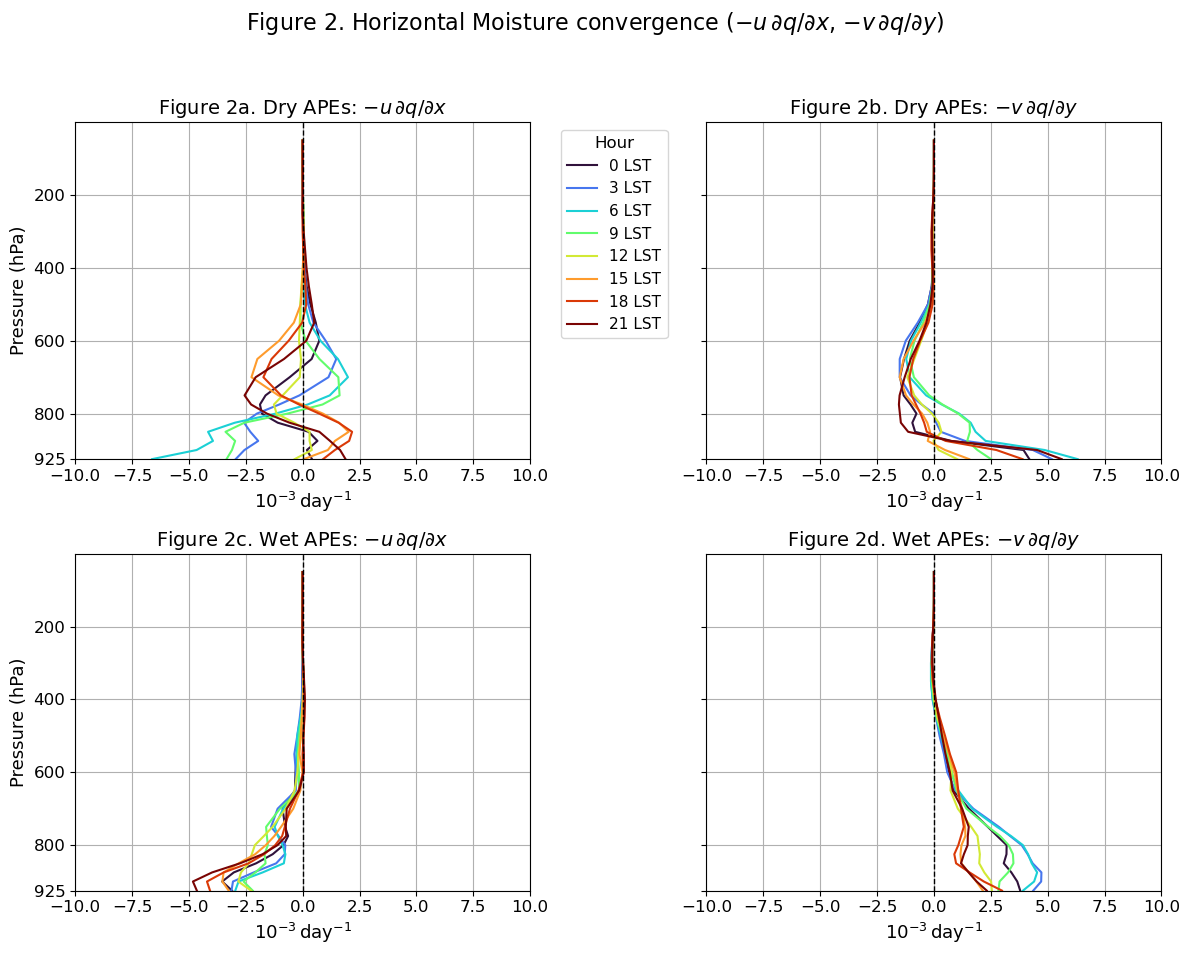

In [4]:
# these are the correct version -> using a single gridpoint to center the APE, and gradients with only adjacent points

folder = Path.home() / "convergence_profiles_single_gridpoint_2001_2025_preapes"

# --- hours you want to plot ---

hours = [0, 3, 6, 9, 12, 15, 18, 21]

# --- storage dictionaries ---

zonal_convergence_data = {}

meridional_convergence_data = {}

# --- load data for each hour ---
for hr in hours:
    
    fp = folder / f"{hr}lst_convergence_profile_preape.pkl"
    
    with open(fp, "rb") as f:
        
        data = pickle.load(f)

    # store
    
    zonal_convergence_data[hr] = data['zonal'] 
    
    meridional_convergence_data[hr] = data['meridional'] 

# --- assume pressure is identical for all files ---

pressure = np.array(pressure)

pressure_masked = pressure[pressure <= 925]

# --- Set up figure ---
colors = plt.cm.turbo(np.linspace(0, 1, len(hours)))

fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

axs = axs.flatten()

titles = [
    r"Figure 2a. Dry APEs: $-u \, \partial q / \partial x$",
    r"Figure 2b. Dry APEs: $-v \, \partial q / \partial y$",
    r"Figure 2c. Wet APEs: $-u \, \partial q / \partial x$",
    r"Figure 2d. Wet APEs: $-v \, \partial q / \partial y$"
]

# plotting loop
for i, hr in enumerate(hours):
    
    color = colors[i]

    # extract profiles, mask to same pressure mask
    
    zon_dry = np.array(zonal_convergence_data[hr]["predry"]*1000)[pressure <= 925]
    
    mer_dry = np.array(meridional_convergence_data[hr]["predry"]*1000)[pressure <= 925]
    
    zon_wet = np.array(zonal_convergence_data[hr]["prewet"]*1000)[pressure <= 925]
    
    mer_wet = np.array(meridional_convergence_data[hr]["prewet"]*1000)[pressure <= 925]

    axs[0].plot(zon_dry, pressure_masked, color=color, label=f"{hr} LST")
    
    axs[1].plot(mer_dry, pressure_masked, color=color)
    
    axs[2].plot(zon_wet, pressure_masked, color=color)
    
    axs[3].plot(mer_wet, pressure_masked, color=color)

# Style subplots
for ax, title in zip(axs, titles):
    
    ax.set_title(title, fontsize=14)
    
    ax.set_xlim(-10, 10)
    
    ax.set_ylim(0, np.max(pressure_masked))
    
    yticks = [925, 800, 600, 400, 200]
    
    ax.set_yticks(yticks)
    
    ax.set_yticklabels([str(int(p)) for p in yticks], fontsize=12)
    
    ax.set_xlabel(r"$10^{-3} \, \mathrm{day}^{-1}$", fontsize=13)
    
    ax.grid(True)
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    
    ax.tick_params(axis='x', labelsize=12)
    
    ax.tick_params(axis='y', labelsize=12)

# labels on left panels
axs[0].set_ylabel("Pressure (hPa)", fontsize=13)

axs[2].set_ylabel("Pressure (hPa)", fontsize=13)

axs[0].legend(title="Hour", fontsize=11, title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle(r"Figure 2. Horizontal Moisture convergence ($-u \, \partial q / \partial x$, $-v \, \partial q / \partial y$)", fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.gca().invert_yaxis()

In [5]:
with open('/home/annierosen16/master_w_sp_2001_2025.pkl', 'rb') as f:
    
    master = pickle.load(f)

### loading surface terms

In [38]:
# Load the pickle file

with open('/home/annierosen16/diurnal_sfc_term_2001_2025_preapes.pkl', 'rb') as f:
    
    data = pickle.load(f)

diurnal_sfc_term_dry = data['dry'] * 1000

diurnal_sfc_term_wet = data['wet'] * 1000

### loading ET

In [28]:
with open('/home/annierosen16/et_composites_2001_2025_preapes.pkl', 'rb') as f:
    
    diurnal_et = pickle.load(f)
    
    diurnal_et_dry = diurnal_et['dry']
    
    diurnal_et_wet = diurnal_et['wet']

### loading precip

In [6]:
dry_case = master[master['predryape']==True]

wet_case = master[master['prewetape']==True]

hr_to_day = 24

# stack daily_precip arrays and compute the hourly average

diurnal_precip_dry = np.vstack(dry_case['daily_precip'].values).mean(axis=0) * hr_to_day

diurnal_precip_wet = np.vstack(wet_case['daily_precip'].values).mean(axis=0) * hr_to_day

### loading vertical flux diff (qw_800 hpa - qw_600 hpa)

In [7]:
file_path = "/home/annierosen16/lt_diurnal_vertical_flux_diff_2001_2025_preapes.pkl"

with open(file_path, "rb") as f:
    
    data = pickle.load(f)

lt_diurnal_vertical_flux_dry = data["dryapes_mean_diurnal_vertical_flux_diff"]

lt_diurnal_vertical_flux_wet = data["wetapes_mean_diurnal_vertical_flux_diff"]

### loading qw800 & qw600

In [8]:
file_path = "/home/annierosen16/_800qw_2001_2025_preapes.pkl"

with open(file_path, "rb") as f:
    
    data = pickle.load(f)

_800qw_dry = data["_800qw_dryapes"]

_800qw_wet = data["_800qw_wetapes"]

In [9]:
file_path = "/home/annierosen16/_600qw_2001_2025_preapes.pkl"

with open(file_path, "rb") as f:
    
    data = pickle.load(f)

_600qw_dry = data["_600qw_dryapes"]

_600qw_wet = data["_600qw_wetapes"]

### uploading separate of BL and LT time tendency 

In [32]:
with open('/home/annierosen16/bl_diurnal_time_tendency_2001_2025_preapes.pkl', 'rb') as f:
    
    bl_data = pickle.load(f)

bl_diurnal_time_tendency_dry = list(bl_data['dry'])

bl_diurnal_time_tendency_wet = list(bl_data['wet'])

with open('/home/annierosen16/lt_diurnal_time_tendency_2001_2025_preapes.pkl', 'rb') as f:
    
    lt_data = pickle.load(f)

lt_diurnal_time_tendency_dry = list(lt_data['dry'])

lt_diurnal_time_tendency_wet = list(lt_data['wet'])

### separating horizontal advection & convergence into BL and LT layers

In [10]:
def apply_pressure_mask(nested_dict, pressure_mask):

    masked_dict = {}

    for outer_key, inner_dict in nested_dict.items():
        
        masked_dict[outer_key] = {}
        
        for inner_key, array in inner_dict.items():
            
            masked_dict[outer_key][inner_key] = array[pressure_mask]
    
    return masked_dict

In [11]:
bl_pressure_mask = (pressure >= 800) & (pressure <= 925)

lt_pressure_mask = (pressure >= 600) & (pressure < 800)

bl_pressure_masked = pressure[bl_pressure_mask]

lt_pressure_masked = pressure[lt_pressure_mask]

In [12]:
# masking for BL

bl_zonal_advection_data = apply_pressure_mask(zonal_advection_data, bl_pressure_mask)

bl_zonal_convergence_data = apply_pressure_mask(zonal_convergence_data, bl_pressure_mask)

bl_meridional_advection_data = apply_pressure_mask(meridional_advection_data, bl_pressure_mask)

bl_meridional_convergence_data = apply_pressure_mask(meridional_convergence_data, bl_pressure_mask)

In [13]:
# masking for LT

lt_zonal_advection_data = apply_pressure_mask(zonal_advection_data, lt_pressure_mask)

lt_zonal_convergence_data = apply_pressure_mask(zonal_convergence_data, lt_pressure_mask)

lt_meridional_advection_data = apply_pressure_mask(meridional_advection_data, lt_pressure_mask)

lt_meridional_convergence_data = apply_pressure_mask(meridional_convergence_data, lt_pressure_mask)

In [14]:
## vertically integrate horizontal convergence & advection

def vertically_integrated_profile_in_pressure(profile, levels):
    
    g = 9.81  # Gravitational acceleration in m/s^2
    
    rho_water = 1000  # Density of water in kg/m^3
    
    m_to_mm = 1000
                    
    dp = np.diff(levels)
            
    integrated_value = (np.sum(0.5 * (profile[:-1] + profile[1:]) * dp) / (g * rho_water)) * m_to_mm

    return integrated_value

def integrate_profiles(data, pressure, unit_adjustment=1000, apply_unit_adjustment=True):
    
    pressure_for_integration = pressure * 100 # conversion to Pa
        
    integrated_profiles = {}

    for time, label_dict in data.items():
        
        integrated_profiles[time] = {}
        
        for label, profile in label_dict.items():
            
            if apply_unit_adjustment:
                
                profile = profile / unit_adjustment
            
            integrated_profiles[time][label] = vertically_integrated_profile_in_pressure(profile, pressure_for_integration)
    
    return integrated_profiles

### integrating for BL

In [15]:
bl_integrated_zonal_advection_profiles = integrate_profiles(bl_zonal_advection_data, bl_pressure_masked, apply_unit_adjustment=False)

bl_integrated_meridional_advection_profiles = integrate_profiles(bl_meridional_advection_data, bl_pressure_masked, apply_unit_adjustment=False)

bl_integrated_zonal_convergence_profiles = integrate_profiles(bl_zonal_convergence_data, bl_pressure_masked, apply_unit_adjustment=False)

bl_integrated_meridional_convergence_profiles = integrate_profiles(bl_meridional_convergence_data, bl_pressure_masked, apply_unit_adjustment=False)

### integrating for LT

In [16]:
lt_integrated_zonal_advection_profiles = integrate_profiles(lt_zonal_advection_data, lt_pressure_masked, apply_unit_adjustment=False)

lt_integrated_meridional_advection_profiles = integrate_profiles(lt_meridional_advection_data, lt_pressure_masked, apply_unit_adjustment=False)

lt_integrated_zonal_convergence_profiles = integrate_profiles(lt_zonal_convergence_data, lt_pressure_masked, apply_unit_adjustment=False)

lt_integrated_meridional_convergence_profiles = integrate_profiles(lt_meridional_convergence_data, lt_pressure_masked, apply_unit_adjustment=False)

### extract diurnal cycles from arrays

In [19]:
def extract_diurnal_cycles(data_dict):
    
    """
    
    data_dict: {hour: {'dry': scalar, 'wet': scalar}}
    
    Returns hours sorted, and dry/wet arrays in that order.
    
    """
    
    sorted_hours = sorted(data_dict.keys())
    
    dry_values = np.array([data_dict[hour]['predry'] for hour in sorted_hours])
    
    wet_values = np.array([data_dict[hour]['prewet'] for hour in sorted_hours])
    
    return sorted_hours, dry_values, wet_values

In [20]:
hours_zonal_adv, bl_diurnal_zonal_advection_dry, bl_diurnal_zonal_advection_wet = extract_diurnal_cycles(bl_integrated_zonal_advection_profiles)

hours_merid_adv, bl_diurnal_meridional_advection_dry, bl_diurnal_meridional_advection_wet = extract_diurnal_cycles(bl_integrated_meridional_advection_profiles)

hours_zonal_conv, bl_diurnal_zonal_convergence_dry, bl_diurnal_zonal_convergence_wet = extract_diurnal_cycles(bl_integrated_zonal_convergence_profiles)

hours_merid_conv, bl_diurnal_meridional_convergence_dry, bl_diurnal_meridional_convergence_wet = extract_diurnal_cycles(bl_integrated_meridional_convergence_profiles)

In [21]:
hours_zonal_adv, lt_diurnal_zonal_advection_dry, lt_diurnal_zonal_advection_wet = extract_diurnal_cycles(lt_integrated_zonal_advection_profiles)

hours_merid_adv, lt_diurnal_meridional_advection_dry, lt_diurnal_meridional_advection_wet = extract_diurnal_cycles(lt_integrated_meridional_advection_profiles)

hours_zonal_conv, lt_diurnal_zonal_convergence_dry, lt_diurnal_zonal_convergence_wet = extract_diurnal_cycles(lt_integrated_zonal_convergence_profiles)

hours_merid_conv, lt_diurnal_meridional_convergence_dry, lt_diurnal_meridional_convergence_wet = extract_diurnal_cycles(lt_integrated_meridional_convergence_profiles)

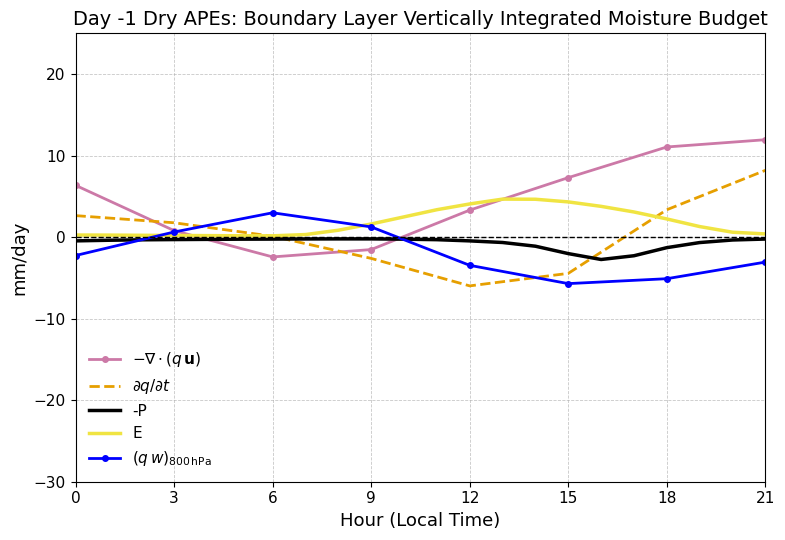

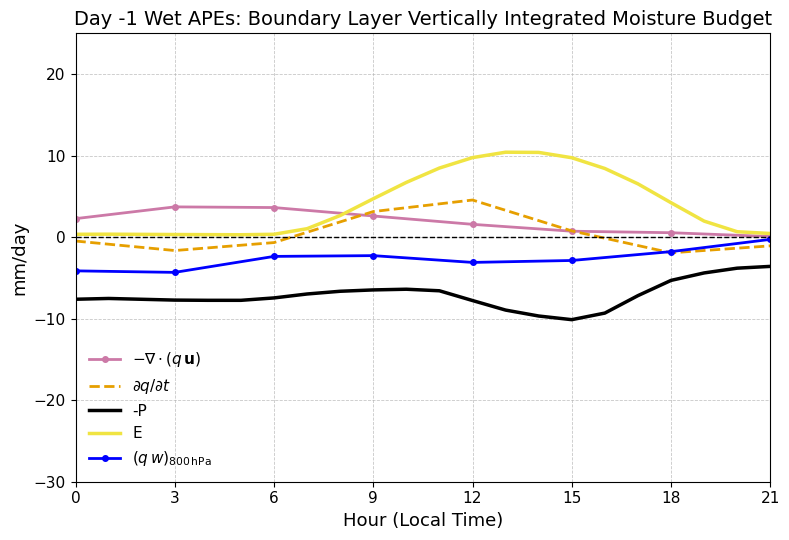

In [39]:
def plot_bl_diurnal_moisture_budget(hours_24, 
                                    precip, 
                                    et, 
                                    mer_adv, 
                                    zon_adv, 
                                    mer_conv, 
                                    zon_conv, 
                                    time_tend, 
                                    sfc_term, 
                                    qw800, 
                                    title):
    
    precip = np.array(precip) * -1 # multiplication by -1 to be consistent with dq/dt = MFC - P + E form of budget
    
    et = np.array(et)
    
    mer_adv = np.array(mer_adv)
    
    zon_adv = np.array(zon_adv)
    
    mer_conv = np.array(mer_conv)
    
    zon_conv = np.array(zon_conv)
    
    time_tend = np.array(time_tend)
    
    sfc_term = np.array(sfc_term)
    
    qw800_term = np.array(qw800)*-1

    # Only take every 3rd element for 3-hourly fields
    
    precip_3hr = precip[::3] * -1 # multiply by -1 to reverse back to positive values for residual calculation
    
    et_3hr = et[::3]
    
    hours_3hr = hours_24[::3]

    adv_total = zon_adv + mer_adv
    
    conv_total = zon_conv + mer_conv
    
    mfc_total = adv_total + conv_total  + sfc_term
        
#     residual = (precip_3hr - et_3hr) + time_tend - adv_total - conv_total - sfc_term
        
    plt.figure(figsize=(8, 5.5))
    
    # Plot 3-hourly budget terms
    
#     plt.plot(hours_3hr, adv_total, label=r'$-\mathbf{u} \cdot \nabla q$', 
#          color='#D55E00', linewidth=2)          # Vermillion

    plt.plot(hours_3hr, mfc_total, label=r'$-\nabla \cdot (q \, \mathbf{u})$', 
         color='#CC79A7', linewidth=2, marker='o', markersize=4)  # Reddish purple

#     plt.plot(hours_3hr, conv_total, label=r'$-q \, \nabla \cdot \mathbf{u}$', 
#          color='#0072B2', linewidth=2)          # Blue

    plt.plot(hours_3hr, time_tend, label=r'$\partial q/\partial t$', 
         color='#E69F00', linestyle='--', linewidth=2)  # Orange

#     plt.plot(hours_3hr, sfc_term, label='sfc', 
#          color='#009E73', linestyle='--', linewidth=2)  # Bluish green

#     plt.plot(hours_3hr, residual, label='residual', 
#          color='#56B4E9', linestyle='--', linewidth=2)  # Sky blue

    plt.plot(hours_24, precip, label='-P', 
         color='#000000', linewidth=2.5)        # Black

    plt.plot(hours_24, et, label='E', 
         color='#F0E442', linewidth=2.5)        # Yellow

    plt.plot(hours_3hr, qw800_term, label=r'$ (q\,w)_{800\,\mathrm{hPa}} $', color='blue', 
         linewidth=2, marker='o', markersize=4)
    
    # Axes and labels
    plt.xlabel('Hour (Local Time)', fontsize=13)
    
    plt.ylabel('mm/day', fontsize=13)
    
    plt.title(title, fontsize=14)
    
    plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)
    
    plt.xticks(range(0, 24, 3), fontsize=11)
    
    plt.yticks(fontsize=11)
    
    plt.xlim(0, 21)
    
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    plt.legend(loc='lower left', fontsize=11, frameon=False)
    
    plt.tight_layout()
    
    plt.ylim(-30, 25)
    
    plt.show()

hours_24 = range(0,24)

# Plot for DRY APEs

plot_bl_diurnal_moisture_budget(
    
    hours_24,
    
    diurnal_precip_dry,
    
    diurnal_et_dry,
    
    bl_diurnal_meridional_advection_dry,
    
    bl_diurnal_zonal_advection_dry,
    
    bl_diurnal_meridional_convergence_dry,
    
    bl_diurnal_zonal_convergence_dry,
    
    bl_diurnal_time_tendency_dry,
    
    diurnal_sfc_term_dry, 
    
    _800qw_dry,
    
    title='Day -1 Dry APEs: Boundary Layer Vertically Integrated Moisture Budget'
)

# Plot for WET APEs

plot_bl_diurnal_moisture_budget(
    
    hours_24,
    
    diurnal_precip_wet,
    
    diurnal_et_wet,
    
    bl_diurnal_meridional_advection_wet,
    
    bl_diurnal_zonal_advection_wet,
    
    bl_diurnal_meridional_convergence_wet,
    
    bl_diurnal_zonal_convergence_wet,
    
    bl_diurnal_time_tendency_wet,
    
    diurnal_sfc_term_wet,
    
    _800qw_wet,
    
    title='Day -1 Wet APEs: Boundary Layer Vertically Integrated Moisture Budget')

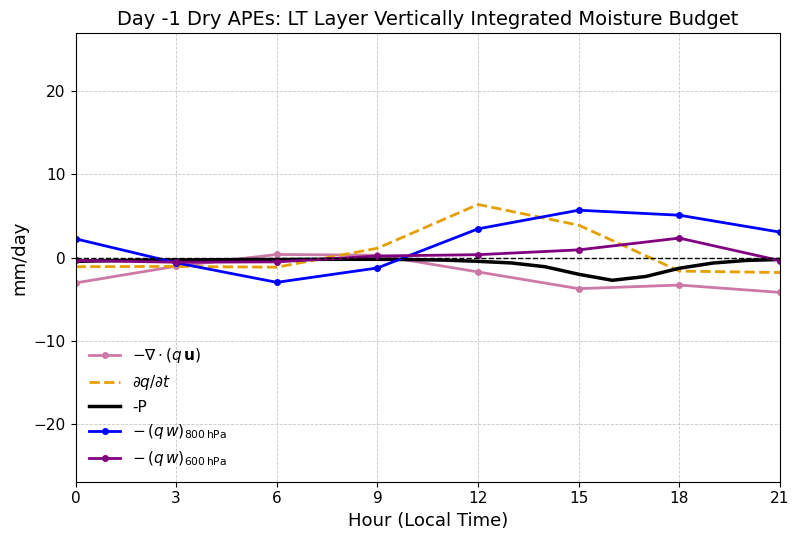

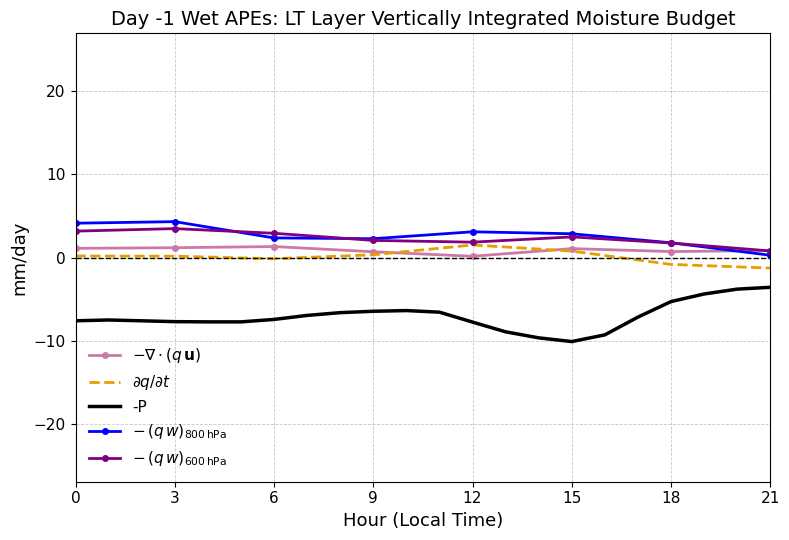

In [41]:
def plot_lt_diurnal_moisture_budget(hours_24, 
                                    precip, 
                                    et, 
                                    mer_adv, 
                                    zon_adv, 
                                    mer_conv, 
                                    zon_conv, 
                                    time_tend, 
                                    sfc_term, 
                                    vertical_flux, 
                                    qw800, 
                                    qw600, 
                                    title):
    
    precip = np.array(precip) * -1 # multiplication by -1 to be consistent with dq/dt = MFC - P + E form of budget
    
    et = np.array(et)
    
    mer_adv = np.array(mer_adv)
    
    zon_adv = np.array(zon_adv)
    
    mer_conv = np.array(mer_conv)
    
    zon_conv = np.array(zon_conv)
    
    time_tend = np.array(time_tend)
    
    sfc_term = np.array(sfc_term)
    
    vert_flux = np.array(vertical_flux)
    
    _800qw = np.array(qw800)
    
    _600qw = np.array(qw600)

    # Only take every 3rd element for 3-hourly fields
    
    precip_3hr = precip[::3] * -1 # multiply by -1 to reverse back to positive values for residual calculation
    
    et_3hr = et[::3]
    
    hours_3hr = hours_24[::3]

    adv_total = zon_adv + mer_adv
    
    conv_total = zon_conv + mer_conv
    
    mfc_total = adv_total + conv_total 
        
#     residual = (precip_3hr - et_3hr) + time_tend - adv_total - conv_total - sfc_term
        
    plt.figure(figsize=(8, 5.5))

    # Plot 3-hourly budget terms
    
#     plt.plot(hours_3hr, adv_total, label=r'$-\mathbf{u} \cdot \nabla q$', 
#          color='#D55E00', linewidth=2)          # Vermillion

    plt.plot(hours_3hr, mfc_total, label=r'$-\nabla \cdot (q \, \mathbf{u})$', 
         color='#CC79A7', linewidth=2, marker='o', markersize=4)  # Reddish purple

#     plt.plot(hours_3hr, conv_total, label=r'$-q \, \nabla \cdot \mathbf{u}$', 
#          color='#0072B2', linewidth=2)          # ltue

    plt.plot(hours_3hr, time_tend, label=r'$\partial q/\partial t$', 
         color='#E69F00', linestyle='--', linewidth=2)  # Orange

#     plt.plot(hours_3hr, sfc_term, label='sfc', 
#          color='#009E73', linestyle='--', linewidth=2)  # ltuish green

#     plt.plot(hours_3hr, residual, label='residual', 
#          color='#56B4E9', linestyle='--', linewidth=2)  # Sky ltue

    plt.plot(hours_24, precip, label='-P', 
         color='#000000', linewidth=2.5)        # black

#     plt.plot(hours_3hr, vert_flux, label=r'$-\left(q\omega_{\mathrm{in}} - q\omega_{\mathrm{out}}\right)$', color='C0', 
#              linewidth=2, marker='o', markersize=4)

    plt.plot(hours_3hr, _800qw, label=r'$-\,(q\,w)_{800\,\mathrm{hPa}}$', color='blue',
             linewidth=2, marker='o', markersize=4)

    plt.plot(hours_3hr, _600qw, label=r'$-\,(q\,w)_{600\,\mathrm{hPa}}$', color='purple',
             linewidth=2, marker='o', markersize=4)

    # Axes and labels
    
    plt.xlabel('Hour (Local Time)', fontsize=13)
    
    plt.ylabel('mm/day', fontsize=13)
    
    plt.title(title, fontsize=14)
    
    plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)
    
    plt.xticks(range(0, 24, 3), fontsize=11)
    
    plt.yticks(fontsize=11)
    
    plt.xlim(0, 21)
    
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    plt.legend(loc='lower left', fontsize=11, frameon=False)
    
    plt.tight_layout()
    
    plt.ylim(-27, 27)
    
    plt.show()

hours_24 = range(0,24)

# Plot for DRY APEs

plot_lt_diurnal_moisture_budget(
    
    hours_24,
    
    diurnal_precip_dry,
    
    diurnal_et_dry,
    
    lt_diurnal_meridional_advection_dry,
    
    lt_diurnal_zonal_advection_dry,
    
    lt_diurnal_meridional_convergence_dry,
    
    lt_diurnal_zonal_convergence_dry,
    
    lt_diurnal_time_tendency_dry,
    
    diurnal_sfc_term_dry, 
    
    lt_diurnal_vertical_flux_dry,
    
    _800qw_dry,
    
    _600qw_dry,
    
    title='Day -1 Dry APEs: LT Layer Vertically Integrated Moisture Budget'
)

# Plot for WET APEs

plot_lt_diurnal_moisture_budget(
    
    hours_24,
    
    diurnal_precip_wet,
    
    diurnal_et_wet,
    
    lt_diurnal_meridional_advection_wet,
    
    lt_diurnal_zonal_advection_wet,
    
    lt_diurnal_meridional_convergence_wet,
    
    lt_diurnal_zonal_convergence_wet,
    
    lt_diurnal_time_tendency_wet,
    
    diurnal_sfc_term_wet,
    
    lt_diurnal_vertical_flux_wet,
    
    _800qw_wet, 
    
    _600qw_wet, 
    
    title='Day -1 Wet APEs: LT Layer Vertically Integrated Moisture Budget')


/tmp/ipykernel_13322/3486643051.py:191: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.90)


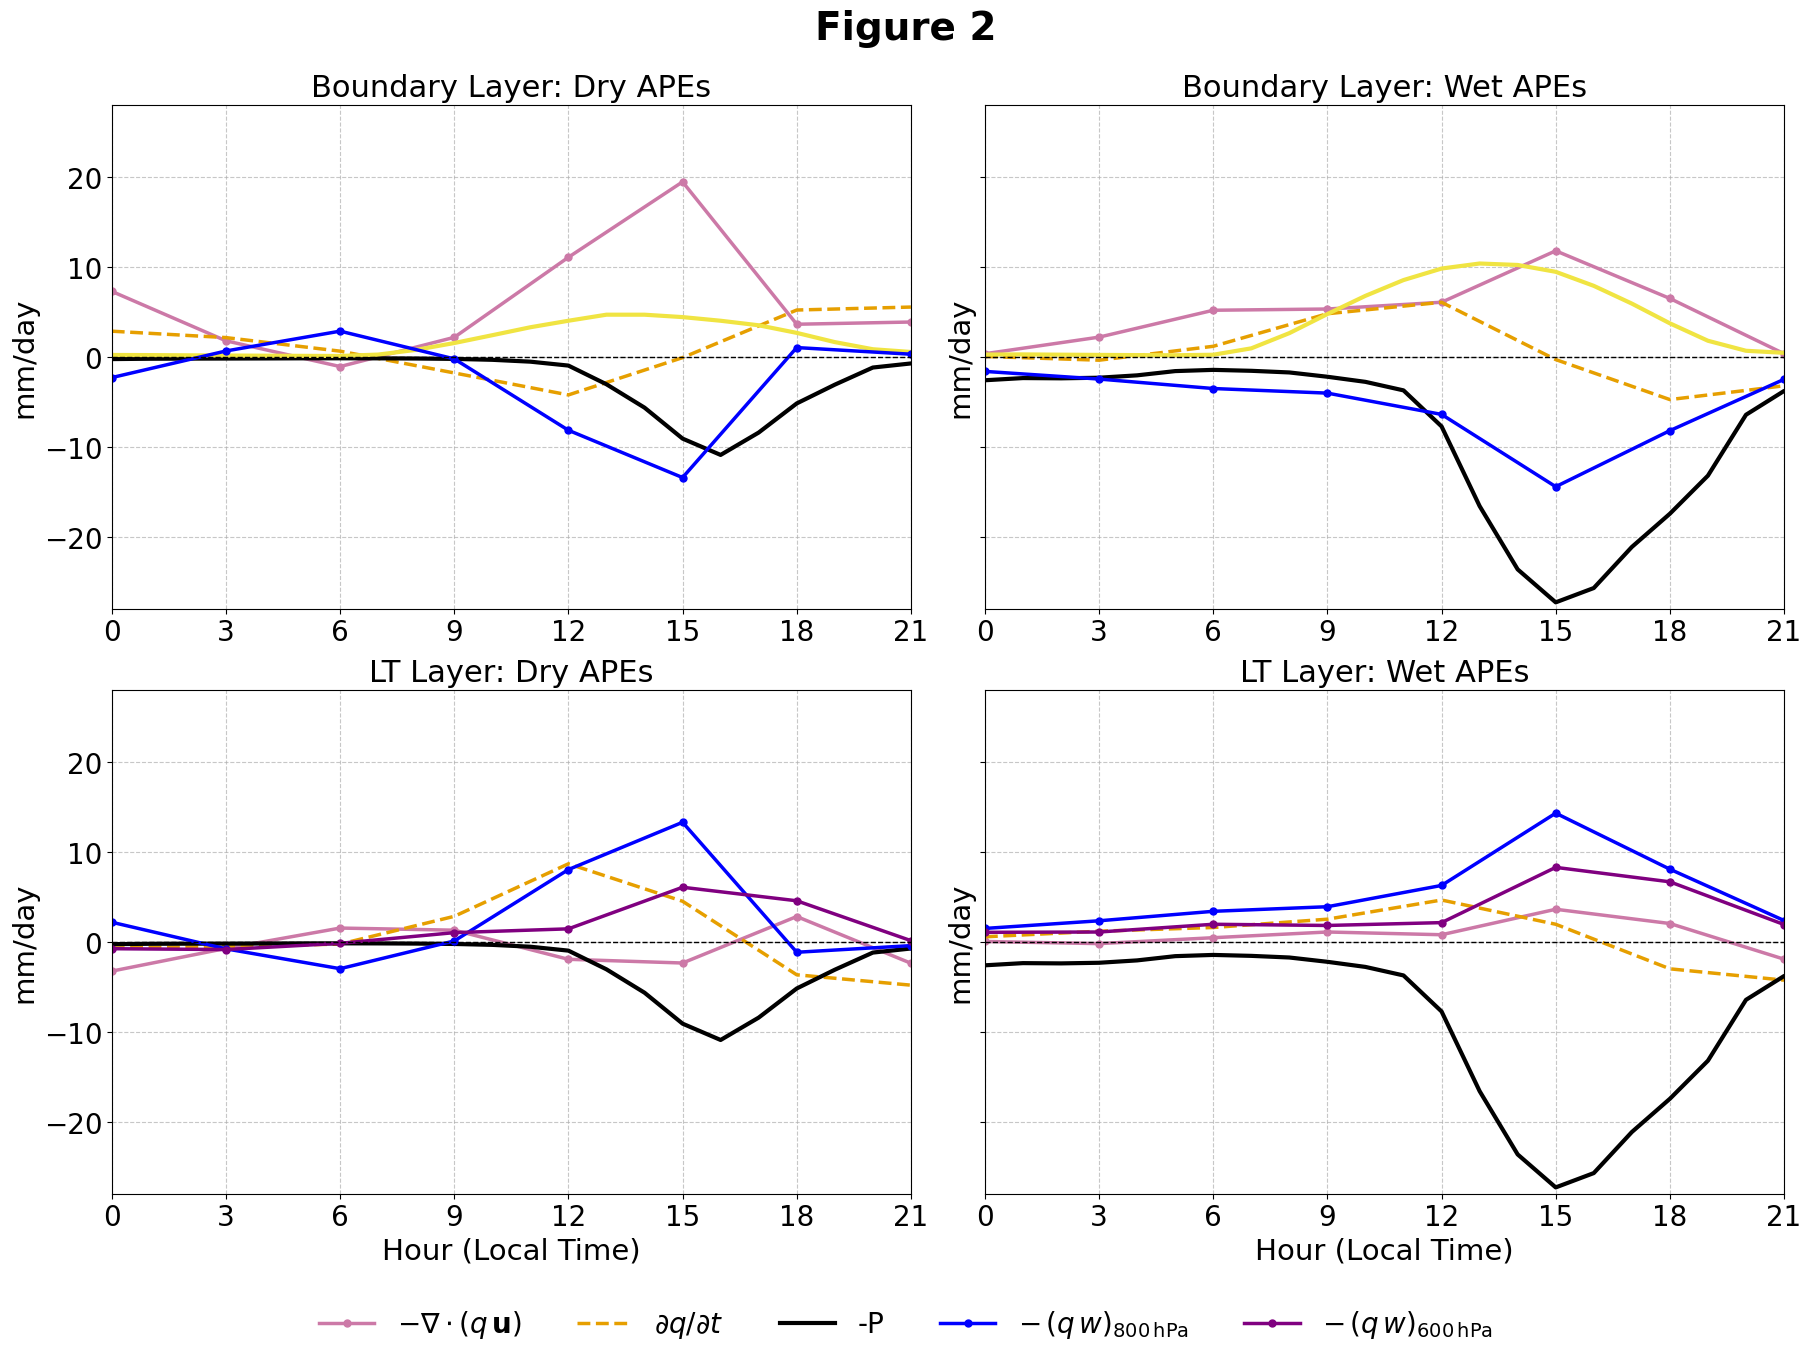

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Global font bump (optional but effective)
# ----------------------------
FS_BUMP = 8  # increase this if you want even bigger

plt.rcParams.update({
    "font.size": 11 + FS_BUMP,
    "axes.titlesize": 12 + FS_BUMP,
    "axes.labelsize": 11 + FS_BUMP,
    "xtick.labelsize": 10 + FS_BUMP,
    "ytick.labelsize": 10 + FS_BUMP,
    "legend.fontsize": 11 + FS_BUMP,
})

# ----------------------------
# 1) LT plotter -> draw on ax
# ----------------------------
def plot_lt_diurnal_moisture_budget_ax(
    ax, hours_24, precip, et, mer_adv, zon_adv, mer_conv, zon_conv,
    time_tend, sfc_term, vertical_flux, qw800, qw600, title,
    base_title_fs=None, base_label_fs=None, base_tick_fs=None
):
    precip   = np.array(precip) * -1  # for budget convention (-P)
    et       = np.array(et)
    mer_adv  = np.array(mer_adv)
    zon_adv  = np.array(zon_adv)
    mer_conv = np.array(mer_conv)
    zon_conv = np.array(zon_conv)
    time_tend = np.array(time_tend)
    sfc_term  = np.array(sfc_term)

    # if you ever want to use this later:
    vert_flux = np.array(vertical_flux)

    # vertical flux components at interfaces (your inputs)
    _800qw = np.array(qw800)
    _600qw = np.array(qw600)

    # 3-hourly sampling
    hours_3hr = np.array(list(hours_24))[::3]
    precip_3hr = precip[::3] * -1
    et_3hr     = et[::3]

    adv_total = zon_adv + mer_adv
    conv_total = zon_conv + mer_conv
    mfc_total = adv_total + conv_total

    residual = (precip_3hr - et_3hr) + time_tend - adv_total - conv_total - sfc_term

    # --- draw ---
    ax.plot(hours_3hr, mfc_total,
            label=r'$-\nabla \cdot (q \, \mathbf{u})$',
            color='#CC79A7', linewidth=2.5, marker='o', markersize=5)

    ax.plot(hours_3hr, time_tend,
            label=r'$\partial q/\partial t$',
            color='#E69F00', linestyle='--', linewidth=2.5)

    ax.plot(list(hours_24), precip,
            label='-P',
            color='#000000', linewidth=3)

    # --- vertical flux components: add negatives in front (SIGN + LABEL) ---
    ax.plot(hours_3hr, _800qw,
            label=r'$-\,(q\,w)_{800\,\mathrm{hPa}}$',
            color='blue', linewidth=2.5, marker='o', markersize=5)

    ax.plot(hours_3hr, _600qw,
            label=r'$-\,(q\,w)_{600\,\mathrm{hPa}}$',
            color='purple', linewidth=2.5, marker='o', markersize=5)

    # --- style ---
    if base_title_fs is not None:
        ax.set_title(title, fontsize=base_title_fs)
    else:
        ax.set_title(title)

    if base_label_fs is not None:
        ax.set_xlabel('Hour (Local Time)', fontsize=base_label_fs)
        ax.set_ylabel('mm/day', fontsize=base_label_fs)
    else:
        ax.set_xlabel('Hour (Local Time)')
        ax.set_ylabel('mm/day')

    if base_tick_fs is not None:
        ax.tick_params(axis='both', which='major', labelsize=base_tick_fs)

    ax.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlim(0, 21)

    # extend y axis to -28 (and keep symmetric)
    ax.set_ylim(-28, 28)

    ax.axhline(0, color='black', linestyle='--', linewidth=1)


# ----------------------------
# 2) BL plotter -> small updates:
#    increase linewidth/markers, y-lims to -28..28
# ----------------------------
def plot_bl_diurnal_moisture_budget_ax(
    ax, hours_24, precip, et, mer_adv, zon_adv, mer_conv, zon_conv,
    time_tend, sfc_term, qw800, title,
    base_title_fs=None, base_label_fs=None, base_tick_fs=None
):
    precip   = np.array(precip) * -1
    et       = np.array(et)
    mer_adv  = np.array(mer_adv)
    zon_adv  = np.array(zon_adv)
    mer_conv = np.array(mer_conv)
    zon_conv = np.array(zon_conv)
    time_tend = np.array(time_tend)
    sfc_term  = np.array(sfc_term)

    # keep your existing BL sign convention for this term
    qw800_term = np.array(qw800) * -1

    hours_3hr = np.array(list(hours_24))[::3]
    precip_3hr = precip[::3] * -1
    et_3hr     = et[::3]

    adv_total  = zon_adv + mer_adv
    conv_total = zon_conv + mer_conv
    mfc_total  = adv_total + conv_total + sfc_term

    residual = (precip_3hr - et_3hr) + time_tend - adv_total - conv_total - sfc_term

    ax.plot(hours_3hr, mfc_total,
            label=r'$-\nabla \cdot (q \, \mathbf{u})$',
            color='#CC79A7', linewidth=2.5, marker='o', markersize=5)

    ax.plot(hours_3hr, time_tend,
            label=r'$\partial q/\partial t$',
            color='#E69F00', linestyle='--', linewidth=2.5)

    ax.plot(list(hours_24), precip,
            label='-P',
            color='#000000', linewidth=3)

    ax.plot(list(hours_24), et,
            label='E',
            color='#F0E442', linewidth=3)

    ax.plot(hours_3hr, qw800_term,
            label=r'$(q\,w)_{800\,\mathrm{hPa}}$',
            color='blue', linewidth=2.5, marker='o', markersize=5)

    if base_title_fs is not None:
        ax.set_title(title, fontsize=base_title_fs)
    else:
        ax.set_title(title)

    if base_label_fs is not None:
#         ax.set_xlabel('Hour (Local Time)', fontsize=base_label_fs)
        ax.set_ylabel('mm/day', fontsize=base_label_fs)
    else:
#         ax.set_xlabel('Hour (Local Time)')
        ax.set_ylabel('mm/day')

    if base_tick_fs is not None:
        ax.tick_params(axis='both', which='major', labelsize=base_tick_fs)

    ax.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlim(0, 21)
    ax.set_ylim(-28, 28)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)


# ----------------------------
# 3) Make the 2x2 figure
# ----------------------------
hours_24 = range(0, 24)

# If you still want explicit control beyond rcParams:
TITLE_FS  = 14 + FS_BUMP
LABEL_FS  = 13 + FS_BUMP
TICK_FS   = 12 + FS_BUMP
SUP_FS    = 20 + FS_BUMP
LEGEND_FS = 12 + FS_BUMP

fig, axs = plt.subplots(
    2, 2, figsize=(18, 12),
    sharex=True, sharey=True,
    constrained_layout=True
)
fig.subplots_adjust(top=0.90)

# --- TOP ROW: BL ---
plot_bl_diurnal_moisture_budget_ax(
    axs[0, 0], hours_24,
    diurnal_precip_dry, diurnal_et_dry,
    bl_diurnal_meridional_advection_dry, bl_diurnal_zonal_advection_dry,
    bl_diurnal_meridional_convergence_dry, bl_diurnal_zonal_convergence_dry,
    bl_diurnal_time_tendency_dry, diurnal_sfc_term_dry,
    _800qw_dry,
    title='Boundary Layer: Dry APEs',
    base_title_fs=TITLE_FS, base_label_fs=LABEL_FS, base_tick_fs=TICK_FS
)

plot_bl_diurnal_moisture_budget_ax(
    axs[0, 1], hours_24,
    diurnal_precip_wet, diurnal_et_wet,
    bl_diurnal_meridional_advection_wet, bl_diurnal_zonal_advection_wet,
    bl_diurnal_meridional_convergence_wet, bl_diurnal_zonal_convergence_wet,
    bl_diurnal_time_tendency_wet, diurnal_sfc_term_wet,
    _800qw_wet,
    title='Boundary Layer: Wet APEs',
    base_title_fs=TITLE_FS, base_label_fs=LABEL_FS, base_tick_fs=TICK_FS
)

# --- BOTTOM ROW: LT ---
plot_lt_diurnal_moisture_budget_ax(
    axs[1, 0], hours_24,
    diurnal_precip_dry, diurnal_et_dry,
    lt_diurnal_meridional_advection_dry, lt_diurnal_zonal_advection_dry,
    lt_diurnal_meridional_convergence_dry, lt_diurnal_zonal_convergence_dry,
    lt_diurnal_time_tendency_dry, diurnal_sfc_term_dry,
    lt_diurnal_vertical_flux_dry,
    _800qw_dry, _600qw_dry,
    title='LT Layer: Dry APEs',
    base_title_fs=TITLE_FS, base_label_fs=LABEL_FS, base_tick_fs=TICK_FS
)

plot_lt_diurnal_moisture_budget_ax(
    axs[1, 1], hours_24,
    diurnal_precip_wet, diurnal_et_wet,
    lt_diurnal_meridional_advection_wet, lt_diurnal_zonal_advection_wet,
    lt_diurnal_meridional_convergence_wet, lt_diurnal_zonal_convergence_wet,
    lt_diurnal_time_tendency_wet, diurnal_sfc_term_wet,
    lt_diurnal_vertical_flux_wet,
    _800qw_wet, _600qw_wet,
    title='LT Layer: Wet APEs',
    base_title_fs=TITLE_FS, base_label_fs=LABEL_FS, base_tick_fs=TICK_FS
)

# Ensure x tick labels appear on ALL panels
for ax in axs.flat:
    ax.tick_params(axis='x', which='both', labelbottom=True)

# Suptitle
fig.suptitle('Figure 2', fontsize=SUP_FS, fontweight='bold', y=1.05)

# Shared legend: build it from a LT axis so it includes the 600 hPa term
handles, labels = axs[1, 0].get_legend_handles_labels()

# Remove per-axes legends if they exist
for ax in axs.flat:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=5,
    frameon=False,
    fontsize=LEGEND_FS,
    bbox_to_anchor=(0.5, -0.08)
)

plt.show()

### analysis on motivation given frequency of APEs and their precip

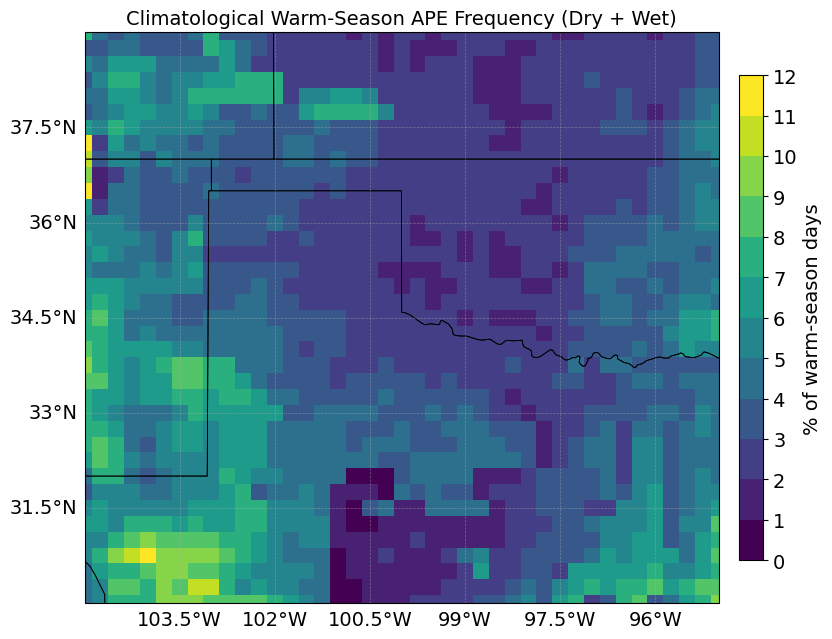

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

df = master.copy()

# --- time + warm season ---
df['date'] = pd.to_datetime(df['date'])
warm_months = [5, 6, 7, 8, 9]
df = df[df['date'].dt.month.isin(warm_months)].copy()

# --- booleans ---
df['dryape'] = df['dryape'].astype(bool)
df['wetape'] = df['wetape'].astype(bool)
df['any_ape'] = df['dryape'] | df['wetape']

# --- frequency ---
ape_freq = (
    df.groupby(['latitude', 'longitude'])['any_ape']
      .mean()
      .mul(100)
      .reset_index(name='ape_pct')
)

grid2d = ape_freq.pivot(index='latitude', columns='longitude', values='ape_pct')

lats = grid2d.index.values
lons = grid2d.columns.values
Z = grid2d.values

# Wrap longitude if needed
if np.nanmax(lons) > 180:
    lons_wrapped = ((lons + 180) % 360) - 180
    order = np.argsort(lons_wrapped)
    lons = lons_wrapped[order]
    Z = Z[:, order]

# --- discrete bins ---
# max_pct = float(np.nanmax(Z))
max_pct = 12
upper = max(1, int(np.ceil(max_pct)))
bins = np.arange(0, upper+1, 1)

cmap = plt.get_cmap('viridis', len(bins)-1)
norm = mcolors.BoundaryNorm(bins, cmap.N, clip=True)

# --- plot ---
FONT = 14
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10.5,6.5))
ax = plt.axes(projection=proj)

ax.set_extent([lons.min(), lons.max(), lats.min(), lats.max()], crs=proj)

ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.6)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.5)

mesh = ax.pcolormesh(
    lons, lats, Z,
    transform=proj,
    shading='auto',
    cmap=cmap,
    norm=norm
)

# ---- LAT/LON GRIDLINES WITH LABELS ----
gl = ax.gridlines(
    crs=proj,
    draw_labels=True,
    linewidth=0.5,
    linestyle='--',
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': FONT}
gl.ylabel_style = {'size': FONT}

# colorbar
cb = plt.colorbar(mesh, ax=ax, pad=0.02, shrink=0.85, ticks=bins)
cb.set_label('% of warm-season days', fontsize=FONT)
cb.ax.tick_params(labelsize=FONT)

ax.set_title('Climatological Warm-Season APE Frequency (Dry + Wet)', fontsize=FONT)

plt.tight_layout()
plt.show()

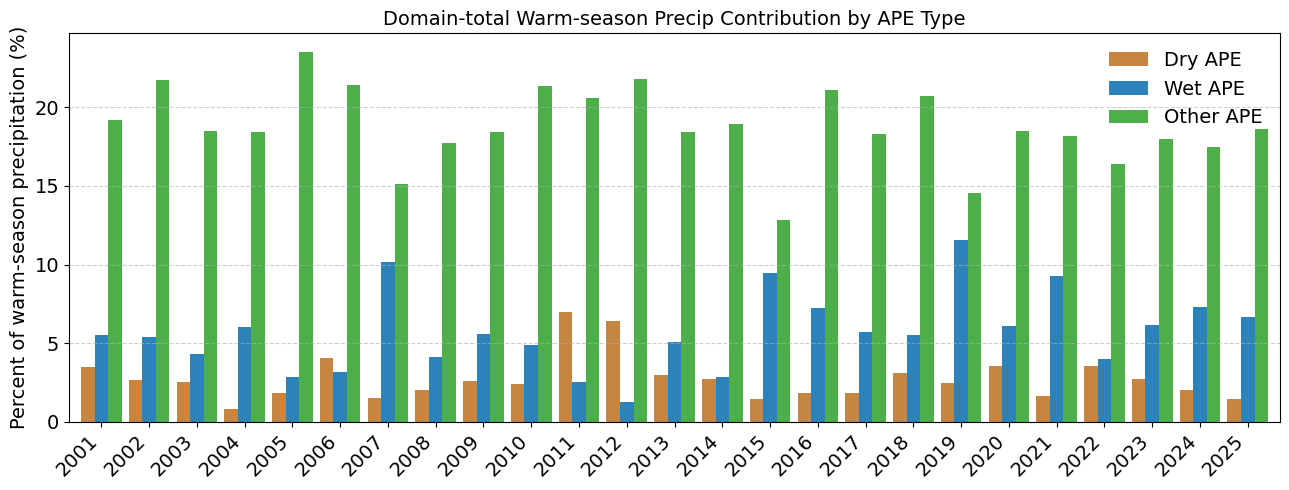

In [14]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

df = master.copy()

df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year

# Warm season filter (MJJAS)

warm_months = [5, 6, 7, 8, 9]

df = df[df['date'].dt.month.isin(warm_months)].copy()

# Ensure booleans

df['dryape'] = df['dryape'].astype(bool)

df['wetape'] = df['wetape'].astype(bool)

df['APE']    = df['APE'].astype(bool)

# 1) Daily total precip at each gridpoint/day (scalar)

def diurnal_to_daily_total(x):
    
    if x is None:
        
        return np.nan
    
    arr = np.asarray(x, dtype=float)
    
    return np.nansum(arr) if arr.shape == (24,) else np.nan

df['daily_total_precip'] = df['daily_precip'].apply(diurnal_to_daily_total)

# Optional: drop malformed/missing precip rows

df = df.dropna(subset=['daily_total_precip']).copy()

# 2) Category contributions (these are true precip attribution)

df['dryP'] = df['daily_total_precip'].where(df['dryape'], 0.0)

df['wetP'] = df['daily_total_precip'].where(df['wetape'], 0.0)

# Optional: APE but neither dry nor wet

df['other_ape'] = df['APE'] & ~(df['dryape'] | df['wetape'])

df['othP'] = df['daily_total_precip'].where(df['other_ape'], 0.0)

# 3) Domain-total sums by year (denominator = total precip across all gridpoints+days)
yearly = (
    
    df.groupby('year')
      .agg(
          
          totalP=('daily_total_precip', 'sum'),
          
          dryP=('dryP', 'sum'),
          
          wetP=('wetP', 'sum'),
          
          othP=('othP', 'sum')
      )
)

# 4) Convert to percentages of total warm-season precip

pct = yearly[['dryP','wetP','othP']].div(yearly['totalP'], axis=0) * 100.0

pct.columns = ['Dry APE', 'Wet APE', 'Other APE']

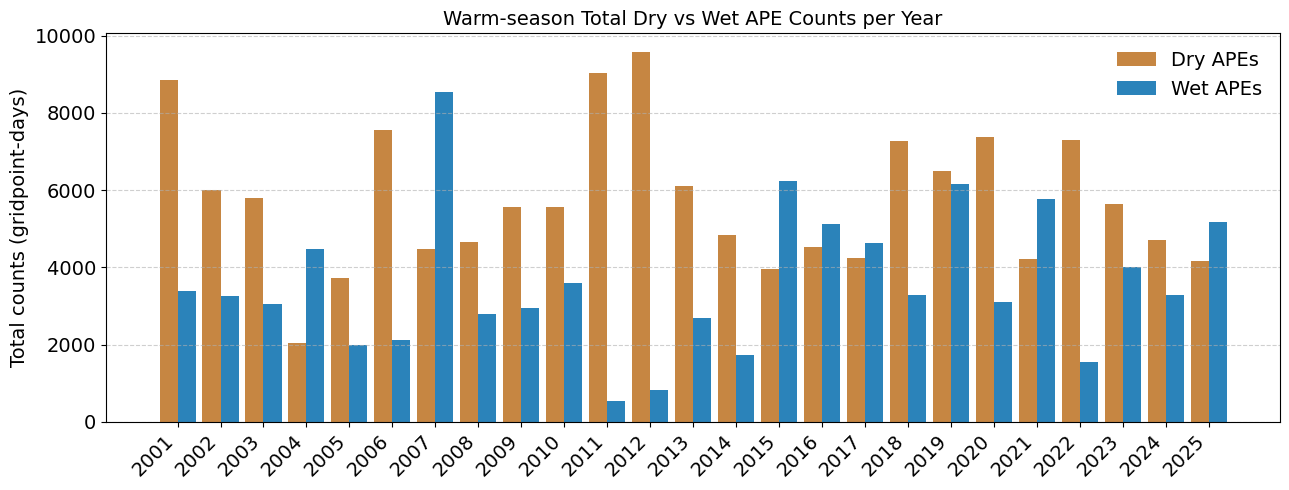

In [19]:
FONT = 14

ax = pct.plot(kind='bar', figsize=(13,5), width=0.85,
              color=['#c68642','#2b83ba','#4daf4a'])

ax.set_ylabel('Percent (%)', fontsize=FONT)

ax.set_xlabel('')

ax.set_title('Warm-season Precip Contribution by APE Type', fontsize=FONT)

ax.tick_params(axis='both', labelsize=FONT)

plt.xticks(rotation=45, ha='right')

ax.legend(frameon=False, fontsize=FONT, loc='upper right')

ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

In [17]:
yearly_counts = (
    df.groupby('year')[['dryape','wetape']]
      .sum()
      .reset_index()
)

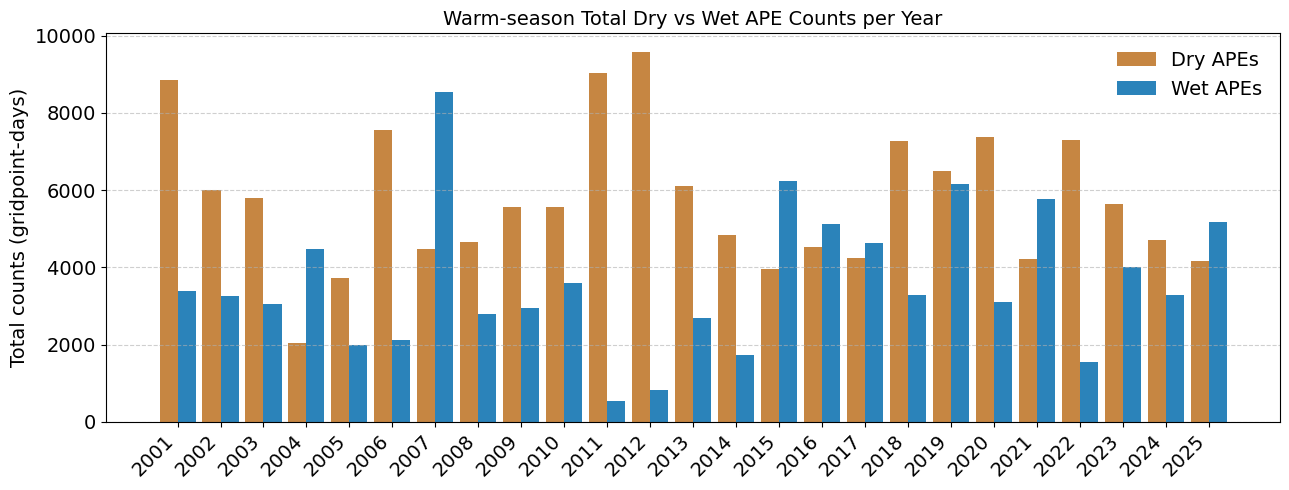

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FONT = 14

df = master.copy()

# --- time handling ---
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# optional warm-season filter
warm_months = [5,6,7,8,9]
df = df[df['date'].dt.month.isin(warm_months)].copy()

# ensure booleans
df['dryape'] = df['dryape'].astype(bool)
df['wetape'] = df['wetape'].astype(bool)

# --- yearly counts ---
yearly = df.groupby('year')[['dryape','wetape']].sum()

# --- ensure ALL years appear ---
all_years = np.arange(df['year'].min(), df['year'].max()+1)
yearly = yearly.reindex(all_years, fill_value=0)

# --- plot ---
x = np.arange(len(yearly.index))
width = 0.42

fig, ax = plt.subplots(figsize=(13,5))

ax.bar(x - width/2, yearly['dryape'], width,
       color='#c68642', label='Dry APEs')

ax.bar(x + width/2, yearly['wetape'], width,
       color='#2b83ba', label='Wet APEs')

# --- styling to match yours ---
ax.set_ylabel('Total counts (gridpoint-days)', fontsize=FONT)
ax.set_xlabel('')
ax.set_title('Warm-season Total Dry vs Wet APE Counts per Year',
             fontsize=FONT)

ax.set_xticks(x)
ax.set_xticklabels(yearly.index)

ax.tick_params(axis='both', labelsize=FONT)

plt.xticks(rotation=45, ha='right')

ax.legend(frameon=False, fontsize=FONT, loc='upper right')

ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [29]:
mask = df['daily_precip'].apply(lambda x: isinstance(x, (list, np.ndarray)) and len(x) == 24)
valid = df.loc[mask, 'daily_precip']
avg_diurnal = np.nanmean(np.stack(valid.to_numpy()), axis=0)

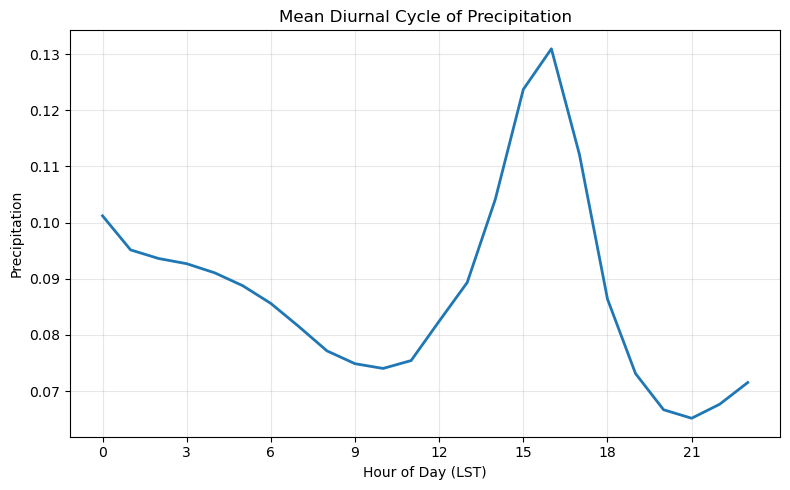

In [30]:
import matplotlib.pyplot as plt
import numpy as np

hours = np.arange(24)

plt.figure(figsize=(8,5))

plt.plot(hours, avg_diurnal, linewidth=2)

plt.xlabel('Hour of Day (LST)')
plt.ylabel('Precipitation')
plt.title('Mean Diurnal Cycle of Precipitation')

plt.xticks(np.arange(0,24,3))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()